# Communities, Education/Employment, Family Structure, and Violent Crime

**STAT 32950 group project notebook**

This notebook builds a reproducible Python analysis for the Communities and Crime dataset.
It focuses on the research theme of education/employment and family/household structure.

Course AI-policy note: use this notebook as coding and analysis scaffolding. The final report
interpretation should be written and checked by the group in your own words.


## Research Question

How are community-level education/employment conditions and family/household structure
associated with violent crime rates, and how well do these variables predict whether a
community has above-median violent crime?

The analysis is observational. Results should be framed as association and prediction, not
as causal evidence.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")

sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("communities_crime.csv")
FIG_DIR = Path("figures")
OUT_DIR = Path("outputs")
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 32950

def savefig(name: str):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"saved {path}")


## 1. Load Data and Define Variable Groups


In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Missing cells: {int(df.isna().sum().sum()):,}")
display(df.head())


Rows: 1,994
Columns: 102
Missing cells: 0


,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,numbUrban,pctUrban,medIncome,pctWWage,pctWFarmSelf,pctWInvInc,pctWSocSec,pctWPubAsst,pctWRetire,medFamInc,perCapInc,whitePerCap,blackPerCap,indianPerCap,AsianPerCap,OtherPerCap,HispPerCap,NumUnderPov,PctPopUnderPov,PctLess9thGrade,PctNotHSGrad,PctBSorMore,PctUnemployed,PctEmploy,PctEmplManu,PctEmplProfServ,PctOccupManu,PctOccupMgmtProf,MalePctDivorce,MalePctNevMarr,FemalePctDiv,TotalPctDiv,PersPerFam,PctFam2Par,PctKids2Par,PctYoungKids2Par,PctTeen2Par,PctWorkMomYoungKids,PctWorkMom,NumIlleg,PctIlleg,NumImmig,PctImmigRecent,PctImmigRec5,PctImmigRec8,PctImmigRec10,PctRecentImmig,PctRecImmig5,PctRecImmig8,PctRecImmig10,PctSpeakEnglOnly,PctNotSpeakEnglWell,PctLargHouseFam,PctLargHouseOccup,PersPerOccupHous,PersPerOwnOccHous,PersPerRentOccHous,PctPersOwnOccup,PctPersDenseHous,PctHousLess3BR,MedNumBR,HousVacant,PctHousOccup,PctHousOwnOcc,PctVacantBoarded,PctVacMore6Mos,MedYrHousBuilt,PctHousNoPhone,PctWOFullPlumb,OwnOccLowQuart,OwnOccMedVal,OwnOccHiQuart,RentLowQ,RentMedian,RentHighQ,MedRent,MedRentPctHousInc,MedOwnCostPctInc,MedOwnCostPctIncNoMtg,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop,HighViolentCrime
0,0.190,0.330,0.020,0.900,0.120,0.170,0.340,0.470,0.290,0.320,0.200,1.000,0.370,0.720,0.340,0.600,0.290,0.150,0.430,0.390,0.400,0.390,0.320,0.270,0.270,0.360,0.410,0.080,0.190,0.100,0.180,0.480,0.270,0.680,0.230,0.410,0.250,0.520,0.680,0.400,0.750,0.750,0.350,0.550,0.590,0.610,0.560,0.740,0.760,0.040,0.140,0.030,0.240,0.270,0.370,0.390,0.070,0.070,0.080,0.080,0.890,0.060,0.140,0.130,0.330,0.390,0.280,0.550,0.090,0.510,0.500,0.210,0.710,0.520,0.050,0.260,0.650,0.140,0.060,0.220,0.190,0.180,0.360,0.350,0.380,0.340,0.380,0.460,0.250,0.040,0.000,0.120,0.420,0.500,0.510,0.640,0.120,0.260,0.200,0.320,0.200,High
1,0.000,0.160,0.120,0.740,0.450,0.070,0.260,0.590,0.350,0.270,0.020,1.000,0.310,0.720,0.110,0.450,0.250,0.290,0.390,0.290,0.370,0.380,0.330,0.160,0.300,0.220,0.350,0.010,0.240,0.140,0.240,0.300,0.270,0.730,0.570,0.150,0.420,0.360,1.000,0.630,0.910,1.000,0.290,0.430,0.470,0.600,0.390,0.460,0.530,0.000,0.240,0.010,0.520,0.620,0.640,0.630,0.250,0.270,0.250,0.230,0.840,0.100,0.160,0.100,0.170,0.290,0.170,0.260,0.200,0.820,0.000,0.020,0.790,0.240,0.020,0.250,0.650,0.160,0.000,0.210,0.200,0.210,0.420,0.380,0.400,0.370,0.290,0.320,0.180,0.000,0.000,0.210,0.500,0.340,0.600,0.520,0.020,0.120,0.450,0.000,0.670,High
2,0.000,0.420,0.490,0.560,0.170,0.040,0.390,0.470,0.280,0.320,0.000,0.000,0.300,0.580,0.190,0.390,0.380,0.400,0.840,0.280,0.270,0.290,0.270,0.070,0.290,0.280,0.390,0.010,0.270,0.270,0.430,0.190,0.360,0.580,0.320,0.290,0.490,0.320,0.630,0.410,0.710,0.700,0.450,0.420,0.440,0.430,0.430,0.710,0.670,0.010,0.460,0.000,0.070,0.060,0.150,0.190,0.020,0.020,0.040,0.050,0.880,0.040,0.200,0.200,0.460,0.520,0.430,0.420,0.150,0.510,0.500,0.010,0.860,0.410,0.290,0.300,0.520,0.470,0.450,0.180,0.170,0.160,0.270,0.290,0.270,0.310,0.480,0.390,0.280,0.000,0.000,0.140,0.490,0.540,0.670,0.560,0.010,0.210,0.020,0.000,0.430,High
3,0.040,0.770,1.000,0.080,0.120,0.100,0.510,0.500,0.340,0.210,0.060,1.000,0.580,0.890,0.210,0.430,0.360,0.200,0.820,0.510,0.360,0.400,0.390,0.160,0.250,0.360,0.440,0.010,0.100,0.090,0.250,0.310,0.330,0.710,0.360,0.450,0.370,0.390,0.340,0.450,0.490,0.440,0.750,0.650,0.540,0.830,0.650,0.850,0.860,0.030,0.330,0.020,0.110,0.200,0.300,0.310,0.050,0.080,0.110,0.110,0.810,0.080,0.560,0.620,0.850,0.770,1.000,0.940,0.120,0.010,0.500,0.010,0.970,0.960,0.600,0.470,0.520,0.110,0.110,0.240,0.210,0.190,0.750,0.700,0.770,0.890,0.630,0.510,0.470,0.000,0.000,0.190,0.300,0.730,0.640,0.650,0.020,0.390,0.280,0.000,0.120,Low
4,0.010,0.550,0.020,0.950,0.090,0.050,0.380,0.380,0.230,0.360,0.020,0.900,0.500,0.720,0.160,0.680,0.440,0.110,0.710,0.460,0.430,0.410,0.280,0.000,0.740,0.510,0.480,0.000,0.060,0.

In [3]:
target_continuous = "ViolentCrimesPerPop"
target_binary = "HighViolentCrime"

education_employment = [
    "PctLess9thGrade", "PctNotHSGrad", "PctBSorMore",
    "PctUnemployed", "PctEmploy",
    "PctEmplManu", "PctEmplProfServ",
    "PctOccupManu", "PctOccupMgmtProf",
]

family_household = [
    "householdsize", "MalePctDivorce", "MalePctNevMarr",
    "FemalePctDiv", "TotalPctDiv", "PersPerFam",
    "PctFam2Par", "PctKids2Par", "PctYoungKids2Par", "PctTeen2Par",
    "PctWorkMomYoungKids", "PctWorkMom",
    "PctIlleg", "PctLargHouseFam", "PctLargHouseOccup",
    "PersPerOccupHous", "PersPerOwnOccHous", "PersPerRentOccHous",
    "PctPersOwnOccup", "PctPersDenseHous", "PctHousLess3BR",
    "MedNumBR", "PctHousOccup", "PctHousOwnOcc",
]

income_poverty = [
    "medIncome", "medFamInc", "perCapInc",
    "NumUnderPov", "PctPopUnderPov",
    "pctWWage", "pctWInvInc", "pctWPubAsst", "pctWRetire",
]

urbanization_housing_controls = [
    "population", "numbUrban", "pctUrban", "LandArea", "PopDens",
    "HousVacant", "PctVacantBoarded", "PctVacMore6Mos",
    "MedRent", "MedRentPctHousInc",
]

demographic_sensitivity_controls = [
    "racepctblack", "racePctWhite", "racePctAsian", "racePctHisp",
    "agePct12t21", "agePct12t29", "agePct16t24", "agePct65up",
    "PctForeignBorn", "PctSpeakEnglOnly", "PctNotSpeakEnglWell",
]

def existing(cols):
    return [c for c in cols if c in df.columns]

education_employment = existing(education_employment)
family_household = existing(family_household)
income_poverty = existing(income_poverty)
urbanization_housing_controls = existing(urbanization_housing_controls)
demographic_sensitivity_controls = existing(demographic_sensitivity_controls)

main_features = sorted(set(
    education_employment
    + family_household
    + income_poverty
    + urbanization_housing_controls
))
sensitivity_features = sorted(set(main_features + demographic_sensitivity_controls))

print("Education/employment variables:", len(education_employment))
print(education_employment)
print("\nFamily/household variables:", len(family_household))
print(family_household)
print("\nMain analysis features:", len(main_features))
print("Sensitivity features including demographic controls:", len(sensitivity_features))


Education/employment variables: 9
['PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy', 'PctEmplManu', 'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf']

Family/household variables: 24
['householdsize', 'MalePctDivorce', 'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par', 'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids', 'PctWorkMom', 'PctIlleg', 'PctLargHouseFam', 'PctLargHouseOccup', 'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous', 'PctPersOwnOccup', 'PctPersDenseHous', 'PctHousLess3BR', 'MedNumBR', 'PctHousOccup', 'PctHousOwnOcc']

Main analysis features: 52
Sensitivity features including demographic controls: 63


## 2. Descriptive Exploration


In [4]:
class_balance = (
    df[target_binary]
    .value_counts()
    .rename_axis(target_binary)
    .reset_index(name="n")
)
class_balance["share"] = class_balance["n"] / len(df)

target_summary = df[target_continuous].describe().to_frame("Violent crime rate summary")

display(class_balance)
display(target_summary)


,HighViolentCrime,n,share
0,Low,1001,0.502
1,High,993,0.498


,Violent crime rate summary
count,1994.000
mean,0.238
std,0.233
min,0.000
25%,0.070
50%,0.150
75%,0.330
max,1.000


In [5]:
numeric_df = df.select_dtypes(include=np.number)
target_corr = (
    numeric_df.corr()[target_continuous]
    .drop(labels=[target_continuous], errors="ignore")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_with_violent_crime")
)

target_corr["abs_corr"] = target_corr["corr_with_violent_crime"].abs()
display(target_corr.head(25))

target_corr.to_csv(OUT_DIR / "correlations_with_violent_crime.csv")


,corr_with_violent_crime,abs_corr
PctKids2Par,-0.738,0.738
PctIlleg,0.738,0.738
PctFam2Par,-0.707,0.707
racePctWhite,-0.685,0.685
PctYoungKids2Par,-0.666,0.666
PctTeen2Par,-0.662,0.662
racepctblack,0.631,0.631
pctWInvInc,-0.576,0.576
pctWPubAsst,0.575,0.575
FemalePctDiv,0.556,0.556


In [6]:
selected_for_group_compare = [
    "PctKids2Par", "PctFam2Par", "PctYoungKids2Par", "PctTeen2Par",
    "PctIlleg", "TotalPctDiv", "PctUnemployed", "PctNotHSGrad",
    "PctLess9thGrade", "PctBSorMore", "PctPopUnderPov", "medIncome",
    "PctPersOwnOccup", "PctHousOwnOcc",
]
selected_for_group_compare = existing(selected_for_group_compare)

group_means = df.groupby(target_binary)[selected_for_group_compare + [target_continuous]].mean().T
group_means["High_minus_Low"] = group_means.get("High", np.nan) - group_means.get("Low", np.nan)
group_means = group_means.sort_values("High_minus_Low", key=lambda s: s.abs(), ascending=False)

display(group_means)
group_means.to_csv(OUT_DIR / "high_low_group_means.csv")


HighViolentCrime,High,Low,High_minus_Low
ViolentCrimesPerPop,0.404,0.073,0.331
PctKids2Par,0.489,0.752,-0.263
PctIlleg,0.381,0.120,0.262
PctYoungKids2Par,0.540,0.787,-0.247
PctFam2Par,0.488,0.733,-0.245
PctPopUnderPov,0.410,0.197,0.213
PctTeen2Par,0.477,0.688,-0.212
TotalPctDiv,0.595,0.394,0.201
PctPersOwnOccup,0.464,0.660,-0.196
PctNotHSGrad,0.476,0.292,0.184


saved figures/selected_predictor_boxplots.png


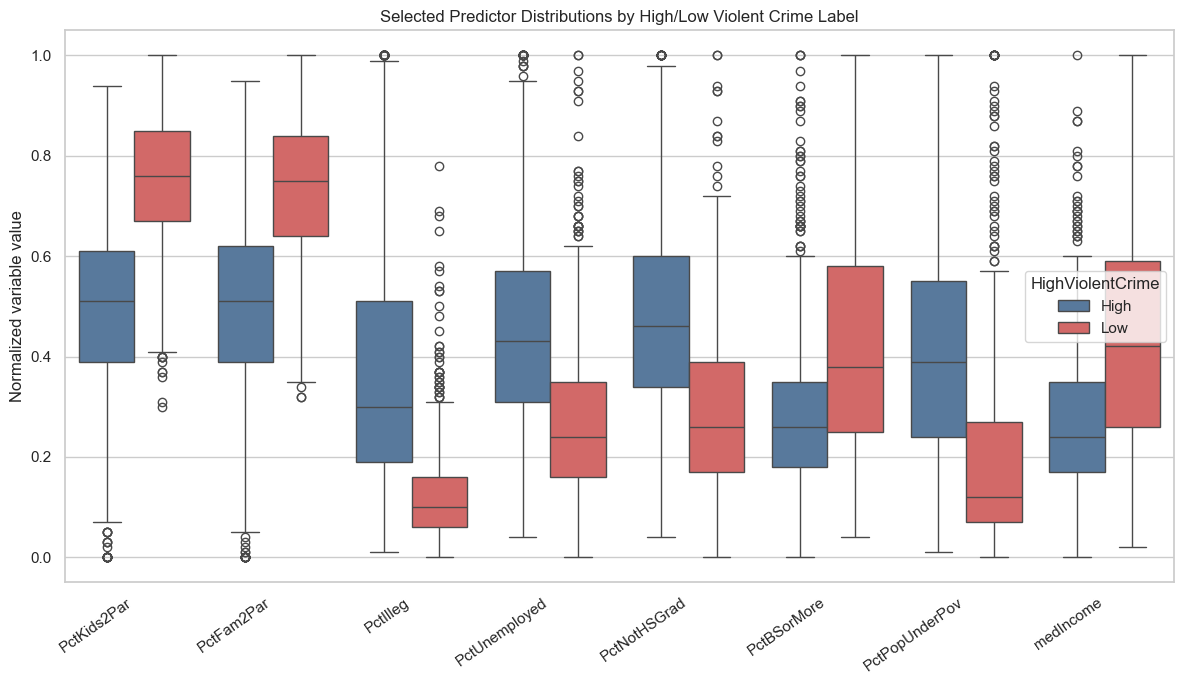

In [7]:
boxplot_vars = [
    "PctKids2Par", "PctFam2Par", "PctIlleg",
    "PctUnemployed", "PctNotHSGrad", "PctBSorMore",
    "PctPopUnderPov", "medIncome",
]
boxplot_vars = existing(boxplot_vars)

plot_df = df[[target_binary] + boxplot_vars].melt(
    id_vars=target_binary,
    var_name="Variable",
    value_name="Value",
)

plt.figure(figsize=(12, 7))
sns.boxplot(data=plot_df, x="Variable", y="Value", hue=target_binary, palette=["#4C78A8", "#E45756"])
plt.xticks(rotation=35, ha="right")
plt.title("Selected Predictor Distributions by High/Low Violent Crime Label")
plt.xlabel("")
plt.ylabel("Normalized variable value")
savefig("selected_predictor_boxplots.png")
plt.show()


saved figures/theme_variable_correlation_heatmap.png


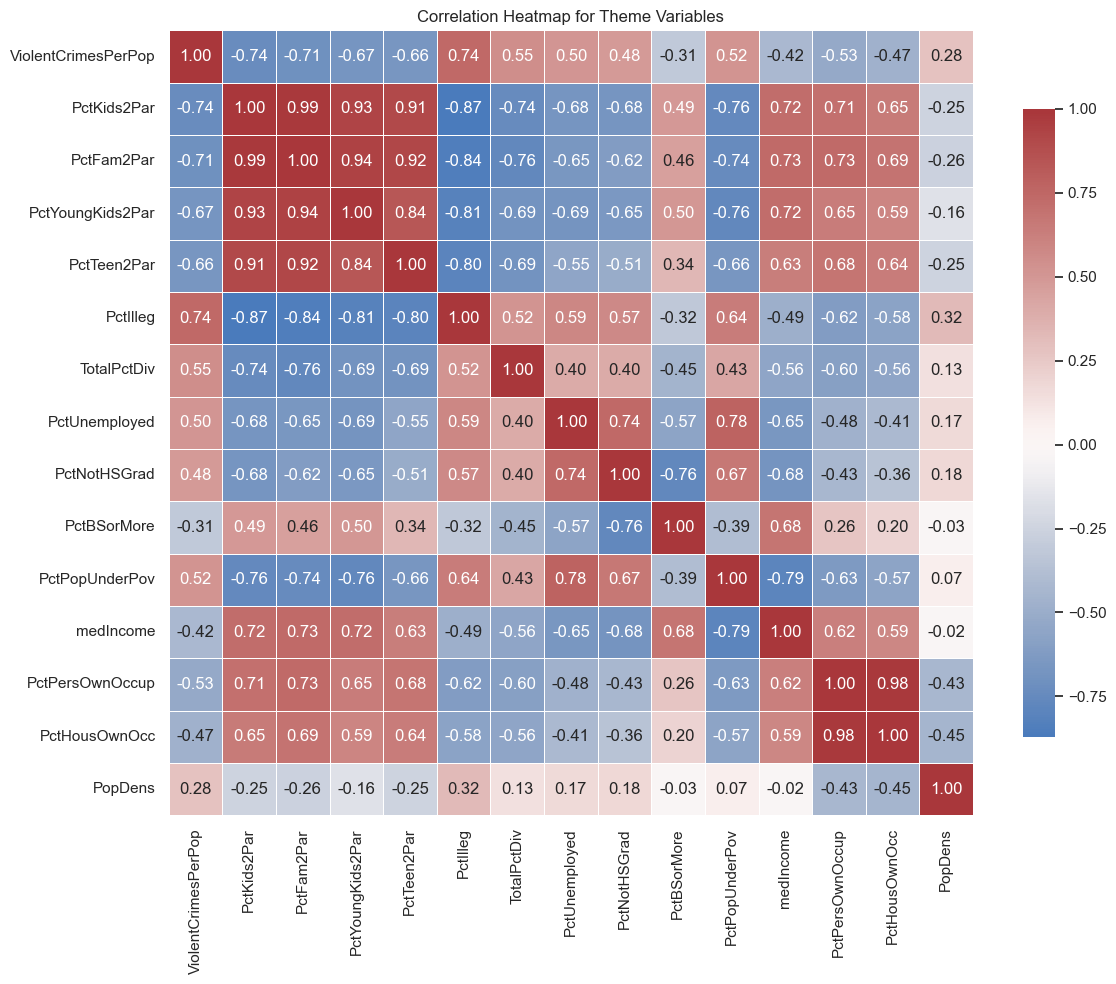

In [8]:
heatmap_vars = [
    target_continuous,
    "PctKids2Par", "PctFam2Par", "PctYoungKids2Par", "PctTeen2Par",
    "PctIlleg", "TotalPctDiv",
    "PctUnemployed", "PctNotHSGrad", "PctBSorMore",
    "PctPopUnderPov", "medIncome",
    "PctPersOwnOccup", "PctHousOwnOcc", "PopDens",
]
heatmap_vars = existing(heatmap_vars)

plt.figure(figsize=(12, 10))
corr = df[heatmap_vars].corr()
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    annot=True,
    fmt="0.2f",
    linewidths=0.4,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap for Theme Variables")
savefig("theme_variable_correlation_heatmap.png")
plt.show()


## 3. Multivariate Structure: PCA

PCA summarizes correlated community characteristics into a smaller number of dimensions.
All variables are standardized first, so the loadings reflect standardized variables.


,PC,explained_variance,cumulative_variance
0,PC1,0.341,0.341
1,PC2,0.153,0.494
2,PC3,0.106,0.600
3,PC4,0.063,0.663
4,PC5,0.061,0.724
5,PC6,0.040,0.764
6,PC7,0.032,0.796
7,PC8,0.030,0.826
8,PC9,0.023,0.849
9,PC10,0.019,0.868


saved figures/pca_cumulative_variance.png


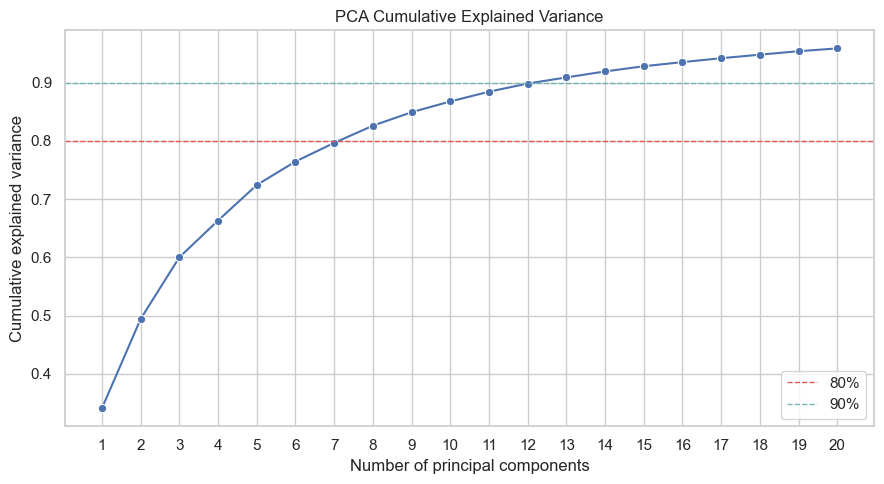

In [9]:
X_main = df[main_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_main)

pca = PCA(random_state=RANDOM_STATE)
pc_scores = pca.fit_transform(X_scaled)

explained = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, len(pca.explained_variance_ratio_) + 1)],
    "explained_variance": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_),
})

display(explained.head(12))

plt.figure(figsize=(9, 5))
sns.lineplot(data=explained.head(20), x=np.arange(1, 21), y="cumulative_variance", marker="o")
plt.axhline(0.80, color="#E45756", linestyle="--", linewidth=1, label="80%")
plt.axhline(0.90, color="#72B7B2", linestyle="--", linewidth=1, label="90%")
plt.xticks(range(1, 21))
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
savefig("pca_cumulative_variance.png")
plt.show()


In [10]:
pc_cols = [f"PC{i}" for i in range(1, len(main_features) + 1)]
scores_df = pd.DataFrame(pc_scores, columns=pc_cols, index=df.index)
scores_df[target_binary] = df[target_binary]
scores_df[target_continuous] = df[target_continuous]

loadings = pd.DataFrame(
    pca.components_.T,
    index=main_features,
    columns=pc_cols,
)

def top_loadings(loadings_df, pc, n=10):
    s = loadings_df[pc].sort_values()
    return pd.concat([
        s.head(n).to_frame("loading"),
        s.tail(n).to_frame("loading"),
    ])

for pc in ["PC1", "PC2", "PC3", "PC4"]:
    print(f"\nTop positive and negative loadings for {pc}")
    display(top_loadings(loadings, pc, n=8))

loadings[["PC1", "PC2", "PC3", "PC4"]].to_csv(OUT_DIR / "pca_loadings_pc1_pc4.csv")
scores_df[["PC1", "PC2", "PC3", "PC4", target_binary, target_continuous]].to_csv(
    OUT_DIR / "pca_scores_pc1_pc4.csv",
    index=False,
)



Top positive and negative loadings for PC1


,loading
pctWPubAsst,-0.202
PctPopUnderPov,-0.200
PctNotHSGrad,-0.194
PctUnemployed,-0.192
PctIlleg,-0.182
PctLess9thGrade,-0.173
TotalPctDiv,-0.168
FemalePctDiv,-0.166
perCapInc,0.186
PctTeen2Par,0.190



Top positive and negative loadings for PC2


,loading
PctWorkMom,-0.148
MalePctDivorce,-0.135
PctWorkMomYoungKids,-0.122
TotalPctDiv,-0.118
pctWRetire,-0.117
PctEmplProfServ,-0.106
FemalePctDiv,-0.096
PctHousLess3BR,-0.093
PctPersDenseHous,0.229
PctLargHouseFam,0.286



Top positive and negative loadings for PC3


,loading
PctOccupManu,-0.200
PctEmplManu,-0.161
PctVacMore6Mos,-0.144
PctHousOwnOcc,-0.135
PctNotHSGrad,-0.129
pctWRetire,-0.122
PctPersOwnOccup,-0.122
PctLess9thGrade,-0.108
PctBSorMore,0.198
pctUrban,0.206



Top positive and negative loadings for PC4


,loading
PctEmploy,-0.279
PctWorkMomYoungKids,-0.250
PctWorkMom,-0.249
PctEmplManu,-0.234
MalePctDivorce,-0.195
LandArea,-0.193
TotalPctDiv,-0.184
pctWWage,-0.182
PctVacMore6Mos,0.101
PctUnemployed,0.128


saved figures/pca_pc1_pc2_by_high_crime.png


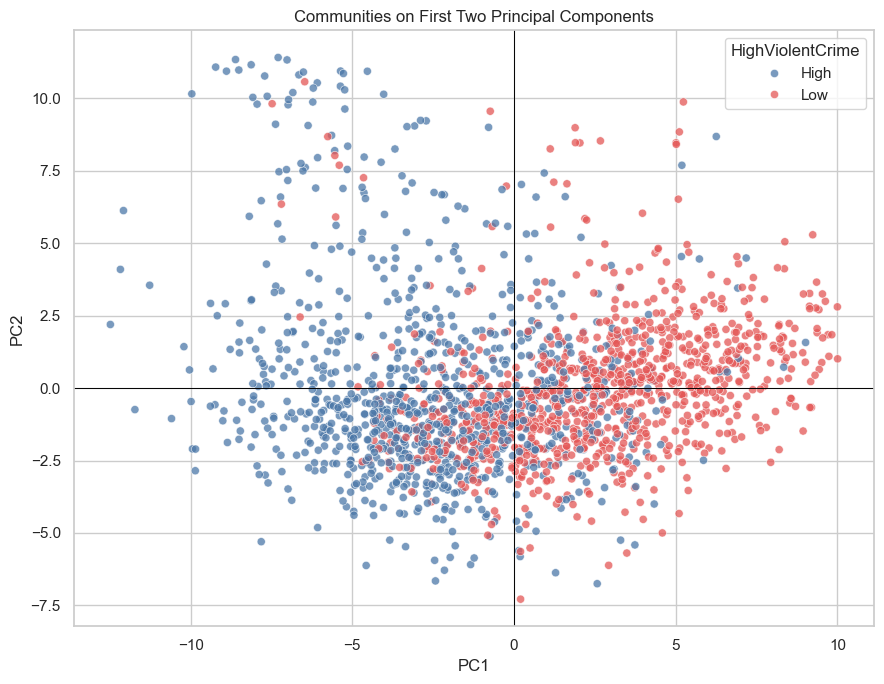

In [11]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=scores_df,
    x="PC1",
    y="PC2",
    hue=target_binary,
    palette=["#4C78A8", "#E45756"],
    alpha=0.75,
    s=35,
)
plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.title("Communities on First Two Principal Components")
savefig("pca_pc1_pc2_by_high_crime.png")
plt.show()


## 4. Multivariate Structure: Clustering on PCA Scores

K-means is fit on the first four PC scores. The clusters are not supervised by crime labels;
we compare crime outcomes afterward.


,k,inertia,silhouette
0,2,44737.553,0.317
1,3,35736.614,0.307
2,4,30658.686,0.325
3,5,25986.562,0.260
4,6,22997.916,0.264
5,7,20713.085,0.242
6,8,19103.179,0.250


saved figures/kmeans_cluster_diagnostics.png


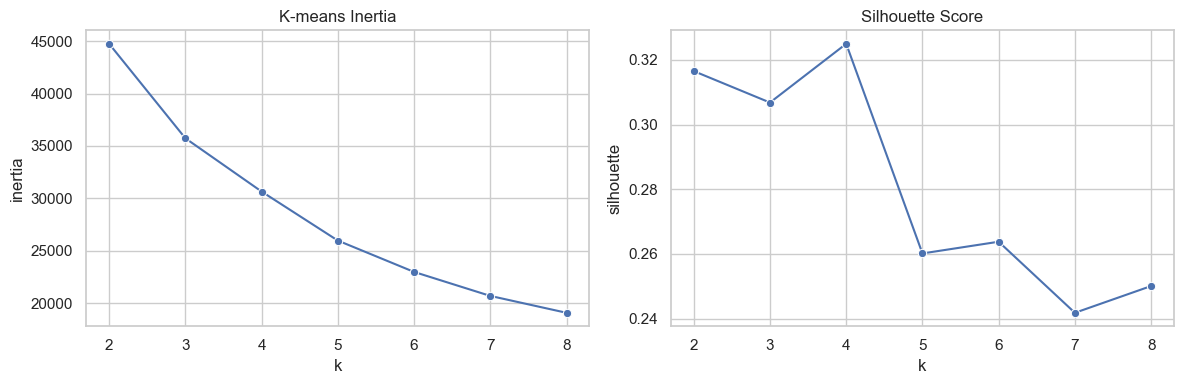

In [12]:
cluster_input = scores_df[["PC1", "PC2", "PC3", "PC4"]]

cluster_diagnostics = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
    labels = km.fit_predict(cluster_input)
    cluster_diagnostics.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(cluster_input, labels),
    })

cluster_diag_df = pd.DataFrame(cluster_diagnostics)
display(cluster_diag_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=cluster_diag_df, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("K-means Inertia")
sns.lineplot(data=cluster_diag_df, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score")
savefig("kmeans_cluster_diagnostics.png")
plt.show()


,n,mean_violent_crime,median_violent_crime,high_crime_share,mean_PC1,mean_PC2,mean_PC3,mean_PC4
cluster,,,,,,,,
2,815,0.101,0.080,0.194,4.096,0.358,0.213,-0.060
1,884,0.275,0.210,0.640,-2.132,-1.359,-0.962,0.050
3,176,0.421,0.360,0.864,-4.791,5.953,-0.027,0.898
4,119,0.625,0.640,0.983,-5.131,-1.164,5.725,-1.289


saved figures/kmeans_clusters_on_pca_scores.png


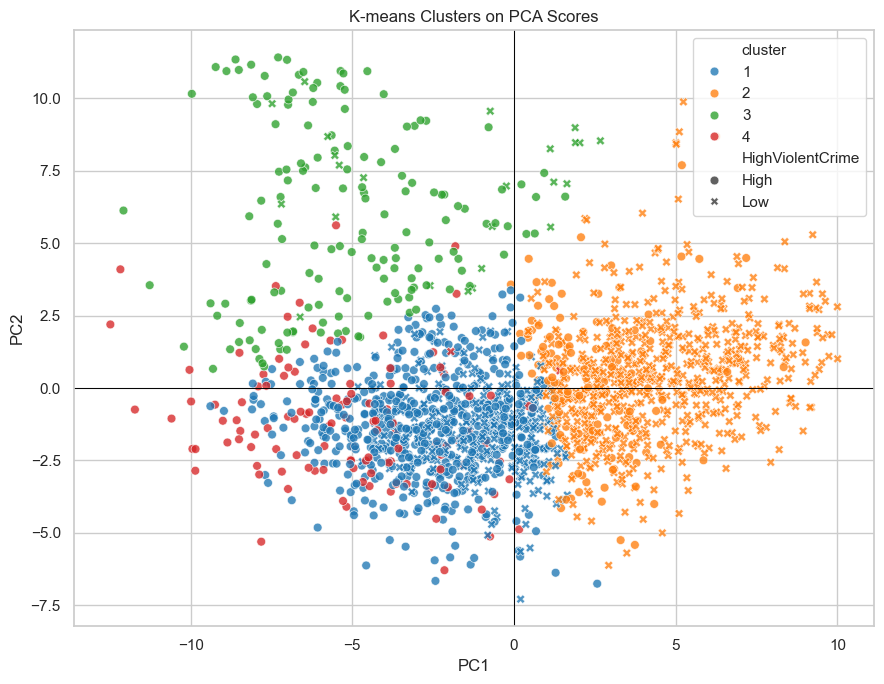

In [13]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=50, random_state=RANDOM_STATE)
scores_df["cluster"] = kmeans.fit_predict(cluster_input) + 1

cluster_summary = (
    scores_df
    .assign(HighCrime=(scores_df[target_binary] == "High").astype(int))
    .groupby("cluster")
    .agg(
        n=("cluster", "size"),
        mean_violent_crime=(target_continuous, "mean"),
        median_violent_crime=(target_continuous, "median"),
        high_crime_share=("HighCrime", "mean"),
        mean_PC1=("PC1", "mean"),
        mean_PC2=("PC2", "mean"),
        mean_PC3=("PC3", "mean"),
        mean_PC4=("PC4", "mean"),
    )
    .sort_values("mean_violent_crime")
)

display(cluster_summary)
cluster_summary.to_csv(OUT_DIR / "kmeans_cluster_summary.csv")

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=scores_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    style=target_binary,
    palette="tab10",
    alpha=0.78,
    s=40,
)
plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.title("K-means Clusters on PCA Scores")
savefig("kmeans_clusters_on_pca_scores.png")
plt.show()


## 5. Supervised Prediction

The main supervised task predicts `HighViolentCrime`. The main model set uses the theme
variables and non-race urbanization/housing controls. A later sensitivity check adds demographic
controls only to show how model performance changes; do not interpret those controls causally.


In [14]:
y = (df[target_binary] == "High").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df[main_features],
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Baseline majority class": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "Logistic regression on PCs": Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=0.85, random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "LDA": Pipeline([
        ("scale", StandardScaler()),
        ("model", LinearDiscriminantAnalysis()),
    ]),
    "Random forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

rows = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        proba = model.decision_function(X_test)

    pred = model.predict(X_test)

    if name == "Baseline majority class":
        cv_auc = 0.500
    else:
        cv_auc = cross_val_score(model, df[main_features], y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

    rows.append({
        "model": name,
        "cv_auc_mean": cv_auc,
        "test_auc": roc_auc_score(y_test, proba),
        "test_accuracy": accuracy_score(y_test, pred),
        "test_f1": f1_score(y_test, pred),
        "test_precision": precision_score(y_test, pred, zero_division=0),
        "test_recall": recall_score(y_test, pred, zero_division=0),
    })

results = pd.DataFrame(rows).sort_values("test_auc", ascending=False)
display(results)
results.to_csv(OUT_DIR / "model_performance_main_features.csv", index=False)


,model,cv_auc_mean,test_auc,test_accuracy,test_f1,test_precision,test_recall
1,Logistic regression,0.914,0.916,0.828,0.830,0.816,0.846
4,Random forest,0.911,0.913,0.823,0.825,0.814,0.836
2,Logistic regression on PCs,0.907,0.910,0.821,0.821,0.817,0.826
3,LDA,0.911,0.910,0.821,0.823,0.811,0.836
0,Baseline majority class,0.500,0.500,0.503,0.000,0.000,0.000


saved figures/supervised_model_roc_curves.png


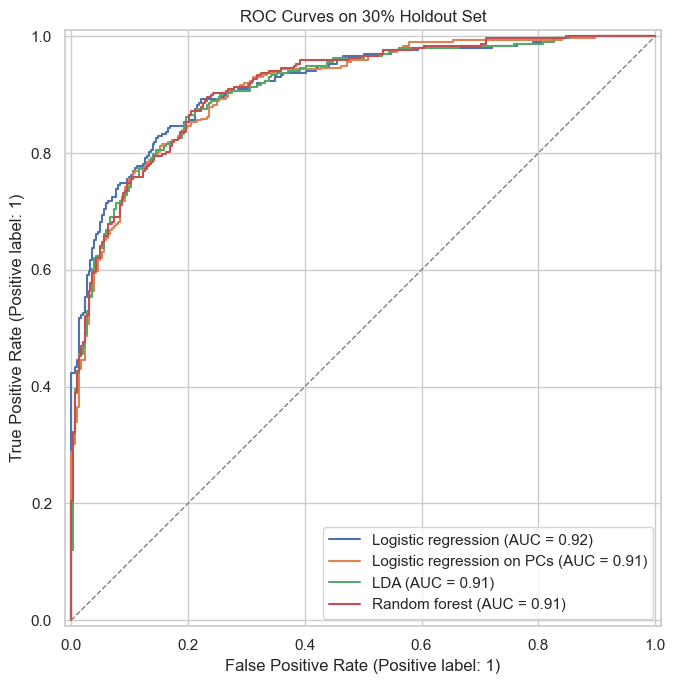

In [15]:
plt.figure(figsize=(8, 7))
ax = plt.gca()
for name, model in fitted_models.items():
    if name == "Baseline majority class":
        continue
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_title("ROC Curves on 30% Holdout Set")
savefig("supervised_model_roc_curves.png")
plt.show()


In [16]:
best_model_name = results.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Low", "Actual High"],
    columns=["Predicted Low", "Predicted High"],
)
print(f"Best model by holdout AUC: {best_model_name}")
display(cm_df)


Best model by holdout AUC: Logistic regression


,Predicted Low,Predicted High
Actual Low,244,57
Actual High,46,252


,standardized_logit_coefficient
PctKids2Par,-1.624
pctWInvInc,-1.088
PersPerOwnOccHous,-0.943
PctPopUnderPov,-0.906
PctWorkMom,-0.645
PctNotHSGrad,-0.607
numbUrban,-0.543
pctWWage,-0.464
PctFam2Par,-0.419
PctLargHouseOccup,-0.412


saved figures/logistic_largest_standardized_coefficients.png


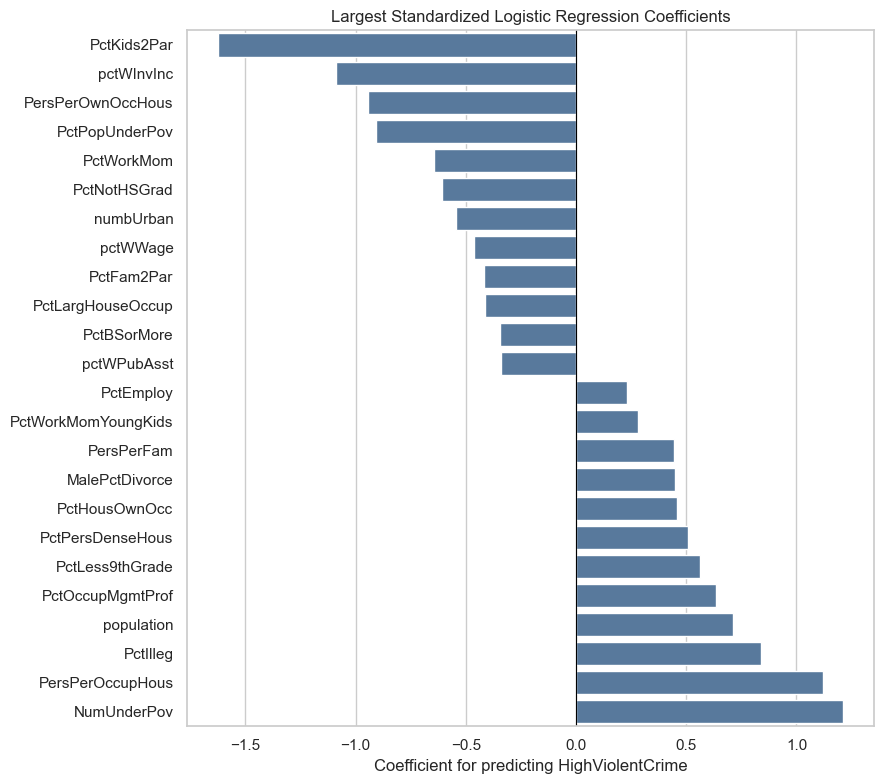

In [17]:
logistic = fitted_models["Logistic regression"]
coef = pd.Series(
    logistic.named_steps["model"].coef_[0],
    index=main_features,
    name="standardized_logit_coefficient",
).sort_values()

coef_table = pd.concat([
    coef.head(12),
    coef.tail(12),
]).to_frame()

display(coef_table)
coef.to_csv(OUT_DIR / "logistic_standardized_coefficients.csv")

plt.figure(figsize=(9, 8))
coef_plot = coef_table.reset_index().rename(columns={"index": "feature"})
sns.barplot(
    data=coef_plot,
    y="feature",
    x="standardized_logit_coefficient",
    color="#4C78A8",
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Largest Standardized Logistic Regression Coefficients")
plt.xlabel("Coefficient for predicting HighViolentCrime")
plt.ylabel("")
savefig("logistic_largest_standardized_coefficients.png")
plt.show()


## 6. Sensitivity Check with Demographic Controls


In [18]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    df[sensitivity_features],
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

sensitivity_models = {
    "Main logistic": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "With demographic controls": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
}

sensitivity_rows = []

sensitivity_models["Main logistic"].fit(X_train, y_train)
p_main = sensitivity_models["Main logistic"].predict_proba(X_test)[:, 1]
sensitivity_rows.append({
    "feature_set": "Theme variables + non-race controls",
    "n_features": len(main_features),
    "test_auc": roc_auc_score(y_test, p_main),
})

sensitivity_models["With demographic controls"].fit(X_train_s, y_train_s)
p_s = sensitivity_models["With demographic controls"].predict_proba(X_test_s)[:, 1]
sensitivity_rows.append({
    "feature_set": "Main features + demographic controls",
    "n_features": len(sensitivity_features),
    "test_auc": roc_auc_score(y_test_s, p_s),
})

sensitivity_results = pd.DataFrame(sensitivity_rows)
display(sensitivity_results)
sensitivity_results.to_csv(OUT_DIR / "demographic_control_sensitivity.csv", index=False)


,feature_set,n_features,test_auc
0,Theme variables + non-race controls,52,0.916
1,Main features + demographic controls,63,0.911


## 7. Method Comparison Notes

Use this table as a report-planning aid. Replace these prompts with the group's own
interpretation in the final written report.


In [19]:
method_comparison = pd.DataFrame([
    {
        "method": "EDA and correlations",
        "question_answered": "Which individual variables differ most between high- and low-crime communities?",
        "primary_output": "Correlation ranking, group means, boxplots, heatmap",
        "report_use": "Motivate feature groups and show initial associations.",
    },
    {
        "method": "PCA",
        "question_answered": "What lower-dimensional structure exists across education, employment, household, income, and housing variables?",
        "primary_output": "Explained variance, PC scores, loading tables",
        "report_use": "Name the main community-level dimensions and compare them with crime outcomes.",
    },
    {
        "method": "K-means on PCA scores",
        "question_answered": "Do unsupervised community profiles differ in violent-crime outcomes?",
        "primary_output": "Cluster summary and PC scatterplot",
        "report_use": "Show whether structure discovered without labels aligns with crime-rate differences.",
    },
    {
        "method": "Logistic regression / LDA / random forest",
        "question_answered": "How well do the selected variables predict above-median violent crime?",
        "primary_output": "AUC, accuracy, F1, ROC curves, coefficients/importances",
        "report_use": "Compare predictive performance with interpretable associations.",
    },
])
display(method_comparison)
method_comparison.to_csv(OUT_DIR / "method_comparison_notes.csv", index=False)


,method,question_answered,primary_output,report_use
0,EDA and correlations,Which individual variables differ most between...,"Correlation ranking, group means, boxplots, he...",Motivate feature groups and show initial assoc...
1,PCA,What lower-dimensional structure exists across...,"Explained variance, PC scores, loading tables",Name the main community-level dimensions and c...
2,K-means on PCA scores,Do unsupervised community profiles differ in v...,Cluster summary and PC scatterplot,Show whether structure discovered without labe...
3,Logistic regression / LDA / random forest,How well do the selected variables predict abo...,"AUC, accuracy, F1, ROC curves, coefficients/im...",Compare predictive performance with interpreta...


## 8. Report Checklist

Recommended final report structure:

1. Research question and dataset description.
2. Preprocessing decisions and variable groups.
3. Descriptive exploration with 1-2 figures.
4. PCA and clustering results.
5. Supervised prediction results.
6. Comparison of what each method reveals.
7. Limitations: observational data, aggregate community-level variables, historical context,
   sensitive demographic variables, no causal claims, and prediction is evaluated on this
   dataset rather than a future population.
8. Group member names and brief AI-use acknowledgment.

Candidate figures/tables for the 3-5 required report visuals:

- selected predictor boxplots by high/low violent-crime label
- correlation heatmap for theme variables
- PCA cumulative explained variance or PC1/PC2 scatterplot
- k-means cluster summary table
- supervised model performance table or ROC curve
